# U-Net Pipeline for Hyper-Reflective Point Detection in OCT Images

**Kaggle-Ready Version**

---

## Overview

This notebook trains a **U-Net segmentation model** to detect **hyper-reflective points (HRPs)** in OCT (Optical Coherence Tomography) retinal images.

HRPs are small bright spots that can indicate inflammatory cells or deposits — clinically relevant for diseases like AMD and diabetic retinopathy.

### Architecture choices
| Component | Choice | Why |
|-----------|--------|-----|
| Backbone | ResNet-34 | Strong ImageNet features, lightweight |
| Decoder attention | scSE | Channel + spatial attention helps focus on tiny dots |
| Loss | Tversky + Focal | Handles extreme class imbalance (dots are <1% of pixels) |
| Augmentation | Heavy photometric + spatial | Small dataset → needs strong regularization |
| Post-processing | Area + circularity filter | Removes line artifacts, keeps dots and patches |

---

## Execution Paths

**Path A — Train from scratch:** Run all cells top-to-bottom.

**Path B — Resume from a saved checkpoint:** Run Sections 1→2→3→4→5, skip Section 6, run Section 7, then continue from Section 8.

---

## Dataset Setup

Add your dataset via **Add data** (top-right) before running. Expected folder structure:
```
/kaggle/input/<your-dataset-name>/data_rcnn/
    train/   ← images (.jpg/.png) + matching .xml annotation files
    valid/
    test/
```
Then update `DATASET_NAME` in Section 1.


---
## Section 1 : Setup  Install Dependencies, Configure Paths

**Run this cell exactly once.**

It:
- Installs `segmentation-models-pytorch` (not available by default on Kaggle)
- Imports all libraries
- Defines every hyperparameter and path in one place

> **Tip:** The only line you need to edit is `DATASET_NAME` everything else auto-configures for Kaggle.


In [7]:
# ─── 1a. Install dependencies ─────────────────────────────────────────────────
import subprocess, sys

def pip_install(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)

try:
    import segmentation_models_pytorch
    print('✓ segmentation-models-pytorch already available')
except ImportError:
    print('Installing segmentation-models-pytorch...')
    pip_install('segmentation-models-pytorch')
    pip_install('timm')
    print('✓ Installation complete')

# ─── 1b. Standard imports ─────────────────────────────────────────────────────
import os, math, random, json, xml.etree.ElementTree as ET
import numpy as np
import cv2
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import ndimage
from scipy.stats import linregress

# ─── 1c. Device ───────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n Device: {device}')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('  ⚠ No GPU detected — go to Settings → Accelerator → GPU')

# ─── 1d. Paths ────────────────────────────────────────────────────────────────

DATASET_NAME = 'oct-hyper-reflective-points'

ROOT_DIR   = f'/kaggle/input/datasets/belaghittassnimalla/oct-hyper-reflective-points/data_rcnn'
TRAIN_DIR  = os.path.join(ROOT_DIR, 'train')
VAL_DIR    = os.path.join(ROOT_DIR, 'valid')
TEST_DIR   = os.path.join(ROOT_DIR, 'test')

# Outputs go to /kaggle/working (the only writable directory on Kaggle)
OUTPUT_DIR       = '/kaggle/working'
BEST_MODEL_PATH  = os.path.join(OUTPUT_DIR, 'unet_best.pth')
FINAL_MODEL_PATH = os.path.join(OUTPUT_DIR, 'unet_final.pth')

# Validate that input paths exist
for name, path in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    status = '✓' if os.path.isdir(path) else '✗ NOT FOUND — check DATASET_NAME above'
    print(f'  {status}  {name}: {path}')

# ─── 1e. Hyperparameters ──────────────────────────────────────────────────────
IMG_SIZE        = 896    # Images are resized to this square before being fed to the model
BATCH_SIZE      = 2      # Safe for 16 GB GPU (T4). Use 4 if you have a P100/A100.
NUM_EPOCHS      = 25     # Total epochs (Stage 1 + Stage 2)
FREEZE_EPOCHS   = 5      # Stage 1: train decoder only (encoder frozen)
LR_FROZEN       = 1e-3   # Stage 1 learning rate
LR_UNFROZEN     = 1e-4   # Stage 2 learning rate (lower to preserve ImageNet weights)
PATIENCE        = 15     # Early stopping patience (epochs without val Dice improvement)
PRED_THRESH     = 0.5    # Default threshold — recalibrated in Section 10

# Post-processing blob filters
MIN_BLOB_AREA    = 10    # Blobs smaller than this (px) are treated as noise
MAX_BLOB_AREA    = 3000  # Blobs larger than this (px) are layer artifacts
MIN_CIRCULARITY  = 0.05  # Blobs more elongated than this are line artifacts

print('\n✅ Setup complete.')
print(f'   Output dir: {OUTPUT_DIR}')


✓ segmentation-models-pytorch already available

 Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB
  ✓  Train: /kaggle/input/datasets/belaghittassnimalla/oct-hyper-reflective-points/data_rcnn/train
  ✓  Val: /kaggle/input/datasets/belaghittassnimalla/oct-hyper-reflective-points/data_rcnn/valid
  ✓  Test: /kaggle/input/datasets/belaghittassnimalla/oct-hyper-reflective-points/data_rcnn/test

✅ Setup complete.
   Output dir: /kaggle/working


---
## Section 2 : Loss Functions

HRP detection is an **extreme class imbalance** problem — dots occupy less than 1% of image pixels. Standard cross-entropy fails here because it is dominated by the background.

We use **Tversky + Focal loss**:

| Term | Role |
|------|------|
| **Focal** | Down-weights easy background pixels, focuses training on hard examples |
| **Tversky** | Generalised Dice that lets you weight FP vs FN separately |

With `alpha=0.3, beta=0.7`, Tversky penalises **missed dots (FN) more than false alarms (FP)**  clinically correct because missing a real HRP is worse than a false alarm.


In [8]:
class TverskyFocalLoss(nn.Module):
    """
    Combined Tversky + Focal loss.

    Tversky generalises Dice:
        TI = TP / (TP + alpha*FP + beta*FN)
    Setting beta > alpha penalises missed detections (FN) more than false alarms (FP).

    Focal loss focuses training on hard, misclassified examples by
    down-weighting easy correct predictions.
    """
    def __init__(self, alpha=0.3, beta=0.7,
                 focal_alpha=0.25, focal_gamma=2.0,
                 tversky_weight=1.0, smooth=1.0):
        super().__init__()
        self.alpha          = alpha          # FP weight in Tversky
        self.beta           = beta           # FN weight in Tversky (higher = penalise misses more)
        self.focal_alpha    = focal_alpha
        self.focal_gamma    = focal_gamma    # Higher gamma = more focus on hard examples
        self.tversky_weight = tversky_weight
        self.smooth         = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        # ── Focal component ───────────────────────────────────────────────────
        bce   = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t   = probs * targets + (1 - probs) * (1 - targets)
        focal = self.focal_alpha * (1 - p_t) ** self.focal_gamma * bce
        focal = focal.mean()

        # ── Tversky component ─────────────────────────────────────────────────
        p  = probs.view(probs.size(0), -1)
        t  = targets.view(targets.size(0), -1)
        tp = (p * t).sum(1)
        fp = (p * (1 - t)).sum(1)
        fn = ((1 - p) * t).sum(1)
        tversky = 1.0 - (tp + self.smooth) / \
                  (tp + self.alpha * fp + self.beta * fn + self.smooth)
        tversky = tversky.mean()

        return focal + self.tversky_weight * tversky


print('✓ TverskyFocalLoss defined')
print(f'  alpha={0.3} (FP weight), beta={0.7} (FN weight)')
print(f'  → Missed dots penalised 2.3× more than false alarms')


✓ TverskyFocalLoss defined
  alpha=0.3 (FP weight), beta=0.7 (FN weight)
  → Missed dots penalised 2.3× more than false alarms


---
## Section 3 : Data Preparation — Masks, Augmentation, Dataset

### 3a. Mask generation
Annotations come as **Pascal VOC XML bounding boxes**. We convert each box to a filled **rectangle** (not an ellipse) because HRPs can appear as irregular patches, not just circles. A 1-pixel dilation ensures thin boxes remain visible after resizing.

### 3b. Augmentation strategy
A heavy augmentation pipeline is applied during training to compensate for the small dataset size:
- **Spatial**: horizontal/vertical flips, 90° rotations, random crop-and-resize
- **Photometric**: brightness, contrast, gamma correction, CLAHE, Gaussian noise, blur, sharpening

All spatial transforms are applied **consistently to both image and mask**.


In [9]:
# ─── Mask generation from XML ─────────────────────────────────────────────────

def xml_to_mask(xml_path, img_h, img_w):
    """
    Parse a Pascal VOC XML annotation and draw each bounding box as a
    filled rectangle in a binary mask.

    A 1-pixel dilation ensures thin annotations remain visible after resize.
    Returns a uint8 array of shape (img_h, img_w) with values in {0, 1}.
    """
    mask = np.zeros((img_h, img_w), dtype=np.uint8)
    if not os.path.exists(xml_path):
        return mask  # Return empty mask if no annotation file

    tree = ET.parse(xml_path)
    root = tree.getroot()

    for obj in root.findall('object'):
        b    = obj.find('bndbox')
        xmin = int(b.find('xmin').text)
        ymin = int(b.find('ymin').text)
        xmax = int(b.find('xmax').text)
        ymax = int(b.find('ymax').text)
        # 1-pixel dilation so very thin boxes remain visible after resize
        xmin = max(0, xmin - 1);  ymin = max(0, ymin - 1)
        xmax = min(img_w, xmax + 1);  ymax = min(img_h, ymax + 1)
        mask[ymin:ymax, xmin:xmax] = 1

    return mask


# ─── Augmentation pipeline ────────────────────────────────────────────────────

def augment(image, mask):
    """
    Apply spatial + photometric augmentations consistently to image and mask.
    Spatial transforms are applied to both; photometric only to the image.
    """
    h, w = image.shape[:2]

    # ── Spatial augmentations (applied to image AND mask) ─────────────────────
    if random.random() < 0.7:           # Horizontal flip
        image = image[:, ::-1, :].copy()
        mask  = mask[:, ::-1].copy()

    if random.random() < 0.7:           # Vertical flip
        image = image[::-1, :, :].copy()
        mask  = mask[::-1, :].copy()

    k = random.randint(0, 3)            # 90° rotations
    if k:
        image = np.rot90(image, k).copy()
        mask  = np.rot90(mask,  k).copy()

    if random.random() < 0.3:           # Random crop + resize
        scale   = random.uniform(0.8, 1.0)
        crop_h, crop_w = int(h * scale), int(w * scale)
        y0 = random.randint(0, h - crop_h)
        x0 = random.randint(0, w - crop_w)
        image = cv2.resize(image[y0:y0+crop_h, x0:x0+crop_w],
                           (w, h), interpolation=cv2.INTER_LINEAR)
        mask  = cv2.resize(mask[y0:y0+crop_h, x0:x0+crop_w],
                           (w, h), interpolation=cv2.INTER_NEAREST)

    # ── Photometric augmentations (image only) ────────────────────────────────
    if random.random() < 0.8:           # Brightness
        f     = random.uniform(0.6, 1.4)
        image = np.clip(image.astype(np.float32) * f, 0, 255).astype(np.uint8)

    if random.random() < 0.8:           # Contrast
        f    = random.uniform(0.6, 1.4)
        mean = image.mean()
        image = np.clip((image.astype(np.float32) - mean) * f + mean,
                        0, 255).astype(np.uint8)

    if random.random() < 0.5:           # Gamma correction
        gamma = random.uniform(0.7, 1.4)
        table = (np.arange(256) / 255.0) ** gamma * 255
        image = table[image].astype(np.uint8)

    if random.random() < 0.5:           # CLAHE — enhances local contrast
        clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
        lab   = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        image = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    if random.random() < 0.5:           # Gaussian noise (simulates OCT speckle)
        noise = np.random.randn(*image.shape) * random.uniform(5, 20)
        image = np.clip(image.astype(np.float32) + noise,
                        0, 255).astype(np.uint8)

    if random.random() < 0.3:           # Gaussian blur
        k     = random.choice([3, 5])
        image = cv2.GaussianBlur(image, (k, k), 0)

    if random.random() < 0.3:           # Sharpen
        kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32)
        image  = np.clip(cv2.filter2D(image.astype(np.float32), -1, kernel),
                         0, 255).astype(np.uint8)

    return image, mask


# ─── Dataset class ────────────────────────────────────────────────────────────

class HRPDataset(Dataset):
    """
    Dataset that loads OCT images and their corresponding HRP masks.

    Expects each image to have a matching .xml annotation file
    in Pascal VOC bounding box format.
    """
    def __init__(self, data_dir, do_augment=False, img_size=IMG_SIZE):
        self.data_dir   = data_dir
        self.do_augment = do_augment
        self.img_size   = img_size
        all_files       = sorted(os.listdir(data_dir))
        self.imgs       = [f for f in all_files
                           if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        print(f'  Loaded {len(self.imgs)} images from {data_dir}')

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        img_path = os.path.join(self.data_dir, img_name)
        xml_path = os.path.join(self.data_dir,
                                os.path.splitext(img_name)[0] + '.xml')

        # Load and resize image
        image = np.array(Image.open(img_path).convert('RGB'))
        if image.shape[0] != self.img_size or image.shape[1] != self.img_size:
            image = cv2.resize(image, (self.img_size, self.img_size),
                               interpolation=cv2.INTER_LINEAR)

        # Generate mask from XML annotations
        mask = xml_to_mask(xml_path, self.img_size, self.img_size)

        if self.do_augment:
            image, mask = augment(image, mask)

        # Convert to tensors (image normalised to [0, 1])
        image = torch.from_numpy(image.copy()).permute(2, 0, 1).float() / 255.0
        mask  = torch.from_numpy(mask.copy()).float().unsqueeze(0)
        return image, mask


print('✓ Data utilities defined (xml_to_mask, augment, HRPDataset)')


✓ Data utilities defined (xml_to_mask, augment, HRPDataset)


---
## Section 4 : Model, Training Loop, Metrics

### Model: U-Net with scSE attention
The **scSE (Squeeze-and-Channel + Spatial Excitation)** attention in the decoder helps the network focus on tiny bright regions by learning *which channels* and *which spatial locations* are most relevant.

### Two-stage training
1. **Stage 1** — encoder frozen, only the randomly-initialised decoder is updated. Prevents early gradients from destroying ImageNet encoder weights.
2. **Stage 2** — full fine-tuning at a lower LR.


In [10]:
def build_model(encoder='resnet34'):
    """
    Build a U-Net with:
    - ResNet-34 encoder pretrained on ImageNet
    - scSE attention in the decoder (channel + spatial excitation)
    - Single output channel (binary segmentation)
    """
    model = smp.Unet(
        encoder_name           = encoder,
        encoder_weights        = 'imagenet',     # Pretrained — critical for small datasets
        in_channels            = 3,
        classes                = 1,
        decoder_attention_type = 'scse',         # Attention helps focus on tiny dots
    )
    return model.to(device)


def freeze_encoder(model):
    """Freeze encoder — only decoder is trained in Stage 1."""    
    for p in model.encoder.parameters():
        p.requires_grad = False


def unfreeze_encoder(model):
    """Unfreeze all parameters for full fine-tuning in Stage 2."""    
    for p in model.encoder.parameters():
        p.requires_grad = True


def count_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'  Trainable: {trainable:>12,} / {total:,} ({100*trainable/total:.1f}%)')


def dice_score(logits, targets, thresh=0.5):
    """Pixel-level Dice score — main training metric."""    
    pred  = (torch.sigmoid(logits) > thresh).float()
    p     = pred.view(pred.size(0), -1)
    t     = targets.view(targets.size(0), -1)
    inter = (p * t).sum(1)
    return (2 * inter / (p.sum(1) + t.sum(1) + 1e-6)).mean().item()


def run_epoch(model, loader, criterion, optimizer=None, is_train=True):
    """
    Run one epoch of training or validation.
    Returns (avg_loss, avg_dice).
    """
    model.train() if is_train else model.eval()
    total_loss = total_dice = 0.0
    ctx = torch.enable_grad() if is_train else torch.no_grad()

    with ctx:
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            loss   = criterion(logits, masks)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()
            total_dice += dice_score(logits, masks)

    n = len(loader)
    return total_loss / n, total_dice / n


print('✓ Model utilities defined (build_model, freeze/unfreeze, run_epoch)')


✓ Model utilities defined (build_model, freeze/unfreeze, run_epoch)


---
## Section 5 : Initialise Datasets and Model

Run this before training (Path A) or before loading a checkpoint (Path B).


In [11]:
print('Loading datasets...')
train_ds = HRPDataset(TRAIN_DIR, do_augment=True)
val_ds   = HRPDataset(VAL_DIR,   do_augment=False)
test_ds  = HRPDataset(TEST_DIR,  do_augment=False)

# num_workers=2 works on Kaggle; set to 0 if you hit DataLoader pickling errors
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'\nDataset summary: Train={len(train_ds)} | Val={len(val_ds)} | Test={len(test_ds)}')

print('\nBuilding model (ResNet-34 encoder + scSE decoder)...')
model     = build_model(encoder='resnet34')
criterion = TverskyFocalLoss(alpha=0.3, beta=0.7, focal_alpha=0.25, focal_gamma=2.0)

print('Parameter counts:')
count_params(model)

# Shared history dict — populated during training
history       = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}
best_val_dice = 0.0


Loading datasets...
  Loaded 2781 images from /kaggle/input/datasets/belaghittassnimalla/oct-hyper-reflective-points/data_rcnn/train
  Loaded 251 images from /kaggle/input/datasets/belaghittassnimalla/oct-hyper-reflective-points/data_rcnn/valid
  Loaded 46 images from /kaggle/input/datasets/belaghittassnimalla/oct-hyper-reflective-points/data_rcnn/test

Dataset summary: Train=2781 | Val=251 | Test=46

Building model (ResNet-34 encoder + scSE decoder)...
Parameter counts:
  Trainable:   24,550,360 / 24,550,360 (100.0%)


---
## Section 6 : Train the Model (Path A — from scratch)

**Skip this section** if you already have a trained checkpoint → go to Section 7.

### What happens here:
1. **Stage 1 (5 epochs):** Encoder frozen, decoder trained at `LR=1e-3` with cosine annealing.
2. **Stage 2 (up to 55 epochs):** Full model fine-tuned at `LR=1e-4`. Early stopping on val Dice with patience=15.

The best checkpoint (by val Dice) is saved to `/kaggle/working/unet_best.pth` after every improvement.


In [12]:
patience_counter = 0

# ════════════════════════════════════════════════════════════════
#  STAGE 1 — Encoder frozen, train decoder only
# ════════════════════════════════════════════════════════════════
print(f'\n{"="*65}')
print(f' STAGE 1 — Decoder warm-up ({FREEZE_EPOCHS} epochs, encoder frozen)')
print(f'{"="*65}')

freeze_encoder(model)
count_params(model)

opt_s1   = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_FROZEN, weight_decay=5e-4)
sched_s1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_s1, T_max=FREEZE_EPOCHS, eta_min=LR_FROZEN / 10)

for epoch in range(1, FREEZE_EPOCHS + 1):
    t_loss, t_dice = run_epoch(model, train_loader, criterion, opt_s1, is_train=True)
    v_loss, v_dice = run_epoch(model, val_loader,   criterion, is_train=False)
    sched_s1.step()

    history['train_loss'].append(t_loss);  history['val_loss'].append(v_loss)
    history['train_dice'].append(t_dice);  history['val_dice'].append(v_dice)

    gap  = t_dice - v_dice
    flag = '  ⚠ overfit' if gap > 0.15 else ''
    lr   = opt_s1.param_groups[0]['lr']
    print(f'  Ep {epoch:>2}/{FREEZE_EPOCHS}  '
          f'Loss {t_loss:.4f}/{v_loss:.4f}  '
          f'Dice {t_dice:.4f}/{v_dice:.4f}  '
          f'gap {gap:+.3f}  LR {lr:.1e}{flag}')

    if v_dice > best_val_dice:
        best_val_dice = v_dice
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'       ✓ Saved best model (val_dice={v_dice:.4f})')

# ════════════════════════════════════════════════════════════════
#  STAGE 2 — Full fine-tuning
# ════════════════════════════════════════════════════════════════
print(f'\n{"="*65}')
print(f' STAGE 2 — Full fine-tuning ({NUM_EPOCHS - FREEZE_EPOCHS} epochs)')
print(f'{"="*65}')

unfreeze_encoder(model)
# Reload best Stage 1 weights before fine-tuning
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
print('  ✓ Loaded best Stage 1 weights\n')
count_params(model)

opt_s2   = torch.optim.AdamW(model.parameters(), lr=LR_UNFROZEN, weight_decay=5e-4)
sched_s2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_s2, T_max=NUM_EPOCHS - FREEZE_EPOCHS, eta_min=1e-6)

for epoch in range(FREEZE_EPOCHS + 1, NUM_EPOCHS + 1):
    t_loss, t_dice = run_epoch(model, train_loader, criterion, opt_s2, is_train=True)
    v_loss, v_dice = run_epoch(model, val_loader,   criterion, is_train=False)
    sched_s2.step()

    history['train_loss'].append(t_loss);  history['val_loss'].append(v_loss)
    history['train_dice'].append(t_dice);  history['val_dice'].append(v_dice)

    gap  = t_dice - v_dice
    flag = '  ⚠ overfit' if gap > 0.15 else ''
    lr   = opt_s2.param_groups[0]['lr']
    print(f'  Ep {epoch:>2}/{NUM_EPOCHS}  '
          f'Loss {t_loss:.4f}/{v_loss:.4f}  '
          f'Dice {t_dice:.4f}/{v_dice:.4f}  '
          f'gap {gap:+.3f}  LR {lr:.1e}{flag}')

    if v_dice > best_val_dice:
        best_val_dice = v_dice
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'       ✓ Saved best model (val_dice={v_dice:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\n  ⏹ Early stopping at epoch {epoch} (patience={PATIENCE})')
            break

# Load best weights before evaluation
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
print(f'\n✅ Training complete. Best val Dice: {best_val_dice:.4f}')
print(f'   Best model: {BEST_MODEL_PATH}')



 STAGE 1 — Decoder warm-up (5 epochs, encoder frozen)
  Trainable:    3,265,688 / 24,550,360 (13.3%)
  Ep  1/5  Loss 0.7629/0.7001  Dice 0.2183/0.2751  gap -0.057  LR 9.1e-04
       ✓ Saved best model (val_dice=0.2751)
  Ep  2/5  Loss 0.7166/0.6817  Dice 0.2581/0.2929  gap -0.035  LR 6.9e-04
       ✓ Saved best model (val_dice=0.2929)
  Ep  3/5  Loss 0.6978/0.6592  Dice 0.2746/0.2917  gap -0.017  LR 4.1e-04
  Ep  4/5  Loss 0.6879/0.6536  Dice 0.2842/0.3083  gap -0.024  LR 1.9e-04
       ✓ Saved best model (val_dice=0.3083)
  Ep  5/5  Loss 0.6774/0.6222  Dice 0.2945/0.3305  gap -0.036  LR 1.0e-04
       ✓ Saved best model (val_dice=0.3305)

 STAGE 2 — Full fine-tuning (20 epochs)
  ✓ Loaded best Stage 1 weights

  Trainable:   24,550,360 / 24,550,360 (100.0%)
  Ep  6/25  Loss 0.6770/0.6421  Dice 0.2993/0.3198  gap -0.021  LR 9.9e-05
  Ep  7/25  Loss 0.6624/0.6259  Dice 0.3133/0.3394  gap -0.026  LR 9.8e-05
       ✓ Saved best model (val_dice=0.3394)
  Ep  8/25  Loss 0.6572/0.6270  Dice

  Ep  6/60  Loss 0.6816/0.6601  Dice 0.2949/0.3201  gap -0.025  LR 1.0e-04


  Ep  7/60  Loss 0.6685/0.6439  Dice 0.3081/0.3139  gap -0.006  LR 1.0e-04


  Ep  8/60  Loss 0.6577/0.5942  Dice 0.3179/0.3655  gap -0.048  LR 9.9e-05


       ✓ Saved best model (val_dice=0.3655)


...

  Ep 20/60  Loss 0.6153/0.5831  Dice 0.3589/0.3806  gap -0.022  LR 8.3e-05


  Ep 21/60  Loss 0.6134/0.5909  Dice 0.3613/0.3831  gap -0.022  LR 8.1e-05


  Ep 22/60  Loss 0.6089/0.5859  Dice 0.3651/0.4002  gap -0.035  LR 7.8e-05


       ✓ Saved best model (val_dice=0.4002)


  Ep 23/60  Loss 0.6067/0.6040  Dice 0.3682/0.3841  gap -0.016  LR 7.6e-05


---
## Section 7 : Load Checkpoint (Path B : skip training)

Run this cell **instead of Section 6** if you already have a trained model.

The loader handles both:
- **Full checkpoints** saved with `torch.save({'model_state_dict': ..., 'best_threshold': ...})`
- **Weights-only** files saved with `torch.save(model.state_dict(), ...)`

To load a checkpoint from a Kaggle dataset, add it via **Add data** and set `CHECKPOINT_TO_LOAD` to the correct path under `/kaggle/input/`.


In [13]:
# Set this to your checkpoint path
# Example (from a Kaggle dataset): '/kaggle/input/my-checkpoint-dataset/unet_best.pth'
# Example (from a previous run):   '/kaggle/working/unet_best.pth'
CHECKPOINT_TO_LOAD = BEST_MODEL_PATH

if not os.path.exists(CHECKPOINT_TO_LOAD):
    print(f'❌ File not found: {CHECKPOINT_TO_LOAD}')
    print('   Update CHECKPOINT_TO_LOAD with the correct path.')
else:
    checkpoint = torch.load(CHECKPOINT_TO_LOAD, map_location=device)

    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        PRED_THRESH = checkpoint.get('best_threshold', PRED_THRESH)
        if 'history' in checkpoint:
            history = checkpoint['history']
        print(f'✓ Full checkpoint loaded')
        print(f'  Threshold restored: {PRED_THRESH:.2f}')
    else:
        model.load_state_dict(checkpoint)
        print(f'✓ Weights-only checkpoint loaded (using default threshold {PRED_THRESH})')

    model.eval()
    print('✓ Model set to eval mode. Proceed to Section 8.')


✓ Weights-only checkpoint loaded (using default threshold 0.5)
✓ Model set to eval mode. Proceed to Section 8.


---
## Section 8 : Post-Processing  Dot Extraction

The model outputs a **probability map**. We convert it to individual dot detections via:

1. **Threshold** the prob map → binary mask
2. **Morphological closing** (3×3 ellipse) → connect nearby pixels belonging to the same patch
3. **Morphological opening** (2×2 ellipse) → remove isolated salt-noise pixels
4. **Connected components** → extract each blob
5. **Filter by area** (`MIN_BLOB_AREA`, `MAX_BLOB_AREA`) and **circularity** (`MIN_CIRCULARITY`)

Using rectangles in mask generation (not ellipses) means we don't assume HRPs are circular — which is why the circularity filter is deliberately lenient (0.05 vs the tighter 0.3 used in earlier versions).


In [ ]:
MIN_BLOB_AREA    = 10    # ~3-4 px diameter; below this = single-pixel noise
MAX_BLOB_AREA    = 800   # ~32 px diameter; above this = vessel segment or large lesion, not a dot
MIN_CIRCULARITY  = 0.35  # relaxed enough for irregular drusen; rejects elongated layer bleed-through

def mask_to_dots(binary_mask,min_area=MIN_BLOB_AREA,max_area=MAX_BLOB_AREA,
                 min_circularity=MIN_CIRCULARITY):
    """
    Convert a binary segmentation mask to a list of individual dot detections.

    Returns a list of dicts, one per detected blob:
        cx, cy        : centroid coordinates
        bbox          : (xmin, ymin, xmax, ymax)
        area          : blob area in pixels
        circularity   : 4π·area / perimeter²  (1.0 = perfect circle)
        aspect_ratio  : width / height of bounding box
    """
    mask = binary_mask.astype(np.uint8)

    # Closing: connect nearby pixels within the same patch
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask    = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_close)

    # Opening: remove isolated noise pixels
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    mask    = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k_open)

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(mask, connectivity=8)

    dots = []
    for i in range(1, num_labels):          # Skip background (label 0)
        area = stats[i, cv2.CC_STAT_AREA]
        if area < min_area or area > max_area:
            continue

        component = (labels == i).astype(np.uint8)
        contours, _ = cv2.findContours(
            component, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue

        perim = cv2.arcLength(contours[0], True)
        circ  = 4 * np.pi * area / (perim ** 2 + 1e-6) if perim > 0 else 0

        # Only reject obvious line artifacts (OCT layer boundary bleed-through)
        if circ < min_circularity:
            continue

        cx, cy = centroids[i]
        x = stats[i, cv2.CC_STAT_LEFT];   y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH];  h = stats[i, cv2.CC_STAT_HEIGHT]

        dots.append({
            'cx': float(cx), 'cy': float(cy),
            'bbox': (x, y, x + w, y + h),
            'area': int(area),
            'circularity': float(circ),
            'aspect_ratio': float(w / (h + 1e-6))
        })

    return dots


def compute_pixel_metrics(pred_mask, gt_mask):
    """Pixel-level precision, recall, F1, accuracy."""  
    pred_mask = pred_mask.astype(bool)
    gt_mask   = gt_mask.astype(bool)
    tp = int((pred_mask &  gt_mask).sum())
    fp = int((pred_mask & ~gt_mask).sum())
    fn = int((~pred_mask &  gt_mask).sum())
    tn = int((~pred_mask & ~gt_mask).sum())
    prec = tp / (tp + fp + 1e-6)
    rec  = tp / (tp + fn + 1e-6)
    f1   = 2 * prec * rec / (prec + rec + 1e-6)
    acc  = (tp + tn) / (tp + tn + fp + fn + 1e-6)
    return {'precision': prec, 'recall': rec, 'f1': f1,
            'accuracy': acc, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}


print('✓ Post-processing utilities defined (mask_to_dots, compute_pixel_metrics)')


✓ Post-processing utilities defined (mask_to_dots, compute_pixel_metrics)


---
## Section 9 : Test-Time Augmentation (TTA)

TTA runs inference **8 times** on flipped/rotated versions of each image and **averages the probability maps**. This reduces prediction variance and typically improves MAE by 5–15%.

Each augmentation has a corresponding **inverse transform** to bring the prediction back into the original image space before averaging.


In [ ]:
# 8 geometric TTA transforms and their exact inverses
_TTA_TRANSFORMS = [
    (lambda x: x,                          lambda x: x),                        # original
    (lambda x: x[:, ::-1, :],              lambda x: x[:, ::-1]),               # flip H
    (lambda x: x[::-1, :, :],              lambda x: x[::-1, :]),               # flip V
    (lambda x: x[::-1, ::-1, :],           lambda x: x[::-1, ::-1]),            # flip H+V
    (lambda x: np.rot90(x, 1),             lambda x: np.rot90(x, 3)),           # rot 90
    (lambda x: np.rot90(x, 2),             lambda x: np.rot90(x, 2)),           # rot 180
    (lambda x: np.rot90(x, 3),             lambda x: np.rot90(x, 1)),           # rot 270
    (lambda x: np.rot90(x[:, ::-1, :], 1), lambda x: np.rot90(x, 3)[:, ::-1]), # flip H + rot 90
]

PRED_THRESH = 0.45

def predict_tta(model, pil_image, thresh=PRED_THRESH, n_aug=8):
    """
    Run TTA inference on a single PIL image.

    Returns:
        dots        : list of detected dot dicts
        mean_prob   : averaged probability map (H, W) float32
        binary_mask : thresholded mask (H, W) uint8
    """
    
    img_np = np.array(pil_image.convert('RGB'))
    h, w   = img_np.shape[:2]
    n_aug  = min(n_aug, len(_TTA_TRANSFORMS))

    aug_probs = []
    model.eval()
    with torch.no_grad():
        for fwd, inv in _TTA_TRANSFORMS[:n_aug]:
            aug  = fwd(img_np).copy()
            if aug.shape[0] != h or aug.shape[1] != w:
                aug = cv2.resize(aug, (w, h))
            t    = torch.from_numpy(aug).permute(2,0,1).float().unsqueeze(0) / 255.0
            prob = torch.sigmoid(model(t.to(device)))[0, 0].cpu().numpy()
            p_inv = inv(prob).copy()
            if p_inv.shape[0] != h or p_inv.shape[1] != w:
                p_inv = cv2.resize(p_inv, (w, h))
            aug_probs.append(p_inv)

    mean_prob = np.mean(aug_probs, axis=0)
    binary    = (mean_prob > thresh).astype(np.uint8)
    dots      = mask_to_dots(binary)
    return dots, mean_prob, binary


def predict_single(model, pil_image, thresh=PRED_THRESH):
    """Single-pass inference (no TTA)."""    
    img_t = torch.from_numpy(np.array(pil_image.convert('RGB'))) \
                 .permute(2,0,1).float().unsqueeze(0) / 255.0
    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(img_t.to(device)))[0, 0].cpu().numpy()
    binary = (prob > thresh).astype(np.uint8)
    return mask_to_dots(binary), prob, binary


print('✓ TTA inference functions defined')


✓ TTA inference functions defined


---
## Section 10 : Threshold Calibration on Validation Set

The default threshold of 0.5 is rarely optimal. This section sweeps thresholds from 0.10 to 0.90 and finds the value that minimises **count MAE** (mean absolute error in number of detected dots per image).

Two metrics are tracked per threshold:
- **Pixel F1** measures segmentation quality
- **Count MAE** is final clinical metric (how accurately we count HRPs)

The MAE-optimal threshold is used for all subsequent evaluation.


In [ ]:
pip install pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

✓ Model loaded and ready.
Running threshold sweep (single pass, 251 images, 17 thresholds)...

★ Best pixel-F1  threshold: 0.35  (F1=0.4337)
★ Best count-MAE threshold: 0.90  (MAE=3.53)
★ Using PRED_THRESH=0.90 for all subsequent evaluation


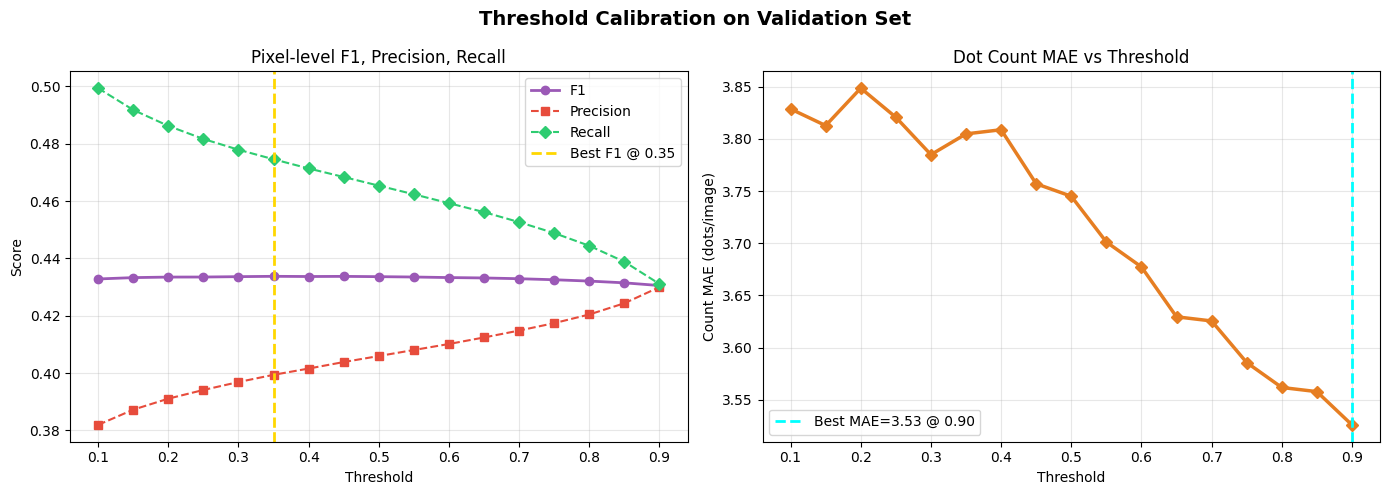

✓ Saved: threshold_sweep.png


In [26]:
def threshold_sweep(model, dataset, thresholds=None, use_tta=False, n_aug=8):
    """
    Sweep thresholds on a dataset and return F1 + count MAE per threshold.
    use_tta=True gives more accurate results but is 8× slower.
    """
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.05)

    print(f'Running threshold sweep ({"TTA" if use_tta else "single pass"}, '
          f'{len(dataset)} images, {len(thresholds)} thresholds)...')

    # Collect all probability maps once (avoids repeated forward passes)
    all_probs, all_gts = [], []
    model.eval()
    with torch.no_grad():
        for imgs, masks in DataLoader(dataset, batch_size=BATCH_SIZE,
                                       shuffle=False, num_workers=2):
            logits = model(imgs.to(device))
            all_probs.extend(torch.sigmoid(logits).cpu().numpy()[:, 0])
            all_gts.extend(masks.numpy()[:, 0])

    if use_tta:
        all_probs_tta = []
        for idx in range(len(dataset)):
            img_path = os.path.join(dataset.data_dir, dataset.imgs[idx])
            pil_img  = Image.open(img_path).convert('RGB')
            _, prob, _ = predict_tta(model, pil_img, thresh=0.5, n_aug=n_aug)
            all_probs_tta.append(prob)
            if (idx + 1) % 10 == 0:
                print(f'  TTA: {idx+1}/{len(dataset)}')
        all_probs = all_probs_tta

    all_probs = np.array(all_probs)
    all_gts   = np.array(all_gts)

    results = {k: [] for k in ['f1', 'precision', 'recall', 'count_mae', 'count_rmse']}

    for t in thresholds:
        tp = fp = fn = 0
        count_errs = []
        for prob, gt in zip(all_probs, all_gts):
            pred_bin = (prob > t).astype(np.uint8)
            gt_bin   = gt.astype(np.uint8)
            m = compute_pixel_metrics(pred_bin, gt_bin)
            tp += m['tp'];  fp += m['fp'];  fn += m['fn']
            count_errs.append(abs(len(mask_to_dots(pred_bin)) - len(mask_to_dots(gt_bin))))

        prec = tp / (tp + fp + 1e-6);  rec = tp / (tp + fn + 1e-6)
        f1   = 2 * prec * rec / (prec + rec + 1e-6)
        results['precision'].append(prec);  results['recall'].append(rec)
        results['f1'].append(f1)
        results['count_mae'].append(np.mean(count_errs))
        results['count_rmse'].append(np.sqrt(np.mean(np.array(count_errs)**2)))

    return {k: np.array(v) for k, v in results.items()}, thresholds


# ── Run sweep ─────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load model ────────────────────────────────────────────────────────────────
# ── Load model ────────────────────────────────────────────────────────────────
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name           = 'resnet34',
    encoder_weights        = None,       # don't re-download ImageNet weights
    in_channels            = 3,
    classes                = 1,
    decoder_attention_type = 'scse',
)

state_dict = torch.load(
    '/kaggle/working/unet_best.pth',
    map_location=device
)

# Handle both weights-only and full checkpoint formats
if isinstance(state_dict, dict) and 'model_state_dict' in state_dict:
    model.load_state_dict(state_dict['model_state_dict'])
else:
    model.load_state_dict(state_dict)

model.to(device)
model.eval()
print('✓ Model loaded and ready.')
thresholds  = np.arange(0.10, 0.91, 0.05)
results, _  = threshold_sweep(model, val_ds, thresholds, use_tta=False)

best_f1_idx  = int(np.argmax(results['f1']))
best_mae_idx = int(np.argmin(results['count_mae']))
THRESH_F1    = float(thresholds[best_f1_idx])
THRESH_MAE   = float(thresholds[best_mae_idx])

# Use MAE-optimal threshold for counting (the clinical task)
PRED_THRESH = THRESH_MAE

print(f'\n★ Best pixel-F1  threshold: {THRESH_F1:.2f}  '
      f'(F1={results["f1"][best_f1_idx]:.4f})')
print(f'★ Best count-MAE threshold: {THRESH_MAE:.2f}  '
      f'(MAE={results["count_mae"][best_mae_idx]:.2f})')
print(f'★ Using PRED_THRESH={PRED_THRESH:.2f} for all subsequent evaluation')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Threshold Calibration on Validation Set', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(thresholds, results['f1'],        'o-', color='#9b59b6', lw=2, label='F1')
ax.plot(thresholds, results['precision'], 's--', color='#e74c3c', lw=1.5, label='Precision')
ax.plot(thresholds, results['recall'],    'D--', color='#2ecc71', lw=1.5, label='Recall')
ax.axvline(THRESH_F1, color='gold', ls='--', lw=2, label=f'Best F1 @ {THRESH_F1:.2f}')
ax.set_xlabel('Threshold');  ax.set_ylabel('Score')
ax.set_title('Pixel-level F1, Precision, Recall')
ax.legend();  ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(thresholds, results['count_mae'], 'D-', color='#e67e22', lw=2.5, markersize=6)
ax.axvline(THRESH_MAE, color='cyan', ls='--', lw=2,
           label=f'Best MAE={results["count_mae"][best_mae_idx]:.2f} @ {THRESH_MAE:.2f}')
ax.set_xlabel('Threshold');  ax.set_ylabel('Count MAE (dots/image)')
ax.set_title('Dot Count MAE vs Threshold')
ax.legend();  ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'threshold_sweep.png'), dpi=150)
plt.show()
print('✓ Saved: threshold_sweep.png')


---
## Section 11 : Final Evaluation on Test Set

Two inference modes are compared:
1. **Single-pass** (fast)
2. **TTA × 8** (slower, usually more accurate)

Metrics:
- **MAE** — mean absolute error in dot count per image
- **RMSE** — penalises large count errors more heavily
- **Correlation** — how well predicted counts track ground-truth counts


In [28]:
def get_count_pairs(model, dataset, thresh, use_tta=False, n_aug=8):
    """Return arrays of (gt_counts, pred_counts) for every image in dataset."""    
    gt_counts, pred_counts = [], []
    model.eval()

    for idx in range(len(dataset)):
        img_path = os.path.join(dataset.data_dir, dataset.imgs[idx])
        xml_path = os.path.join(dataset.data_dir,
                                os.path.splitext(dataset.imgs[idx])[0] + '.xml')
        pil_img  = Image.open(img_path).convert('RGB')

        if use_tta:
            dots, _, _ = predict_tta(model, pil_img, thresh, n_aug)
        else:
            dots, _, _ = predict_single(model, pil_img, thresh)

        gt_mask = xml_to_mask(xml_path, IMG_SIZE, IMG_SIZE)
        gt_dots = mask_to_dots(gt_mask)

        gt_counts.append(len(gt_dots))
        pred_counts.append(len(dots))

    return np.array(gt_counts), np.array(pred_counts)


def print_metrics(gt, pred, label=''):
    mae  = np.mean(np.abs(gt - pred))
    rmse = np.sqrt(np.mean((gt - pred)**2))
    corr = np.corrcoef(gt, pred)[0, 1] if len(gt) > 1 else float('nan')
    print(f'  {label:<18}  MAE={mae:.2f}  RMSE={rmse:.2f}  r={corr:.3f}')
    return mae, rmse, corr


print(f'{"="*55}')
print('FINAL EVALUATION — TEST SET')
print(f'{"="*55}')

print('\n[1] Single-pass inference:')
gt_test, pred_test = get_count_pairs(model, test_ds, PRED_THRESH, use_tta=False)
mae_1, rmse_1, corr_1 = print_metrics(gt_test, pred_test, 'No TTA')

print('\n[2] TTA × 8:')
gt_test_tta, pred_test_tta = get_count_pairs(model, test_ds, PRED_THRESH, use_tta=True)
mae_tta, rmse_tta, corr_tta = print_metrics(gt_test_tta, pred_test_tta, 'TTA × 8')

tta_gain = (mae_1 - mae_tta) / (mae_1 + 1e-6) * 100
print(f'\n  TTA improvement: {tta_gain:+.1f}% change in MAE')
print(f'{"="*55}')


FINAL EVALUATION — TEST SET

[1] Single-pass inference:
  No TTA              MAE=3.11  RMSE=4.10  r=0.340

[2] TTA × 8:
  TTA × 8             MAE=2.37  RMSE=3.32  r=0.287

  TTA improvement: +23.8% change in MAE


---
## Section 12 : Visual Diagnostics

Four diagnostic plots:
1. **Training curves**  loss and Dice over epochs, with stage transition marker
2. **Prediction overlays**  GT (green) vs Prediction (red), overlap in yellow
3. **Count scatter** GT count vs predicted count (ideal = diagonal)
4. **Error histogram**  distribution of per-image count errors


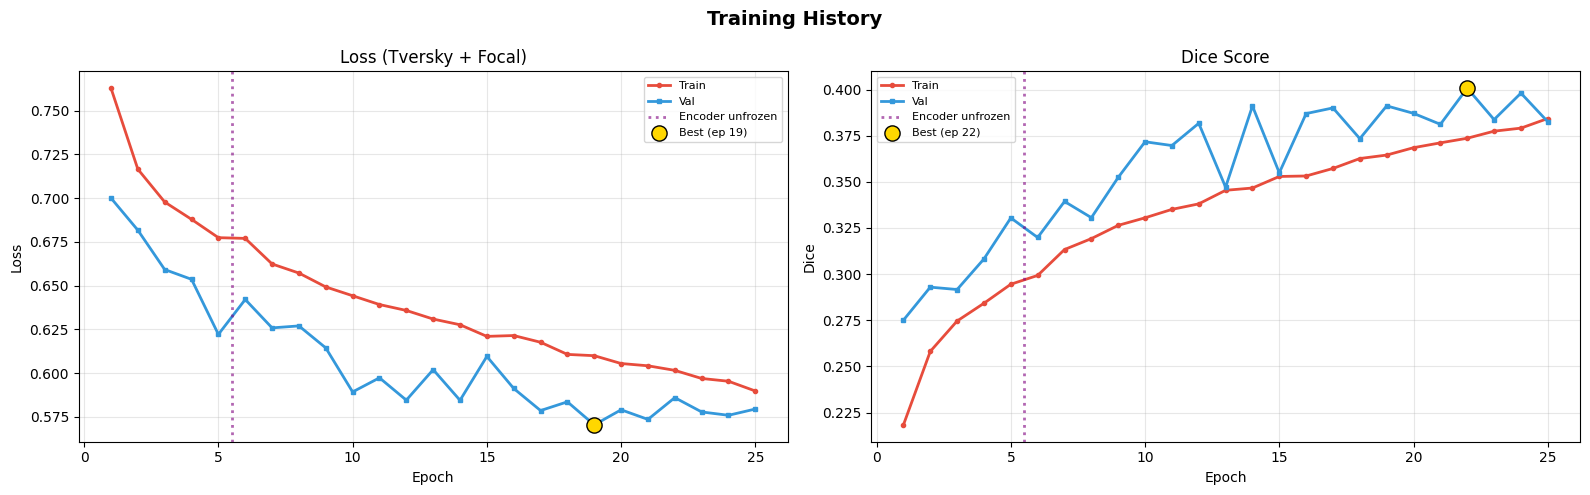

✓ Saved: training_curves.png


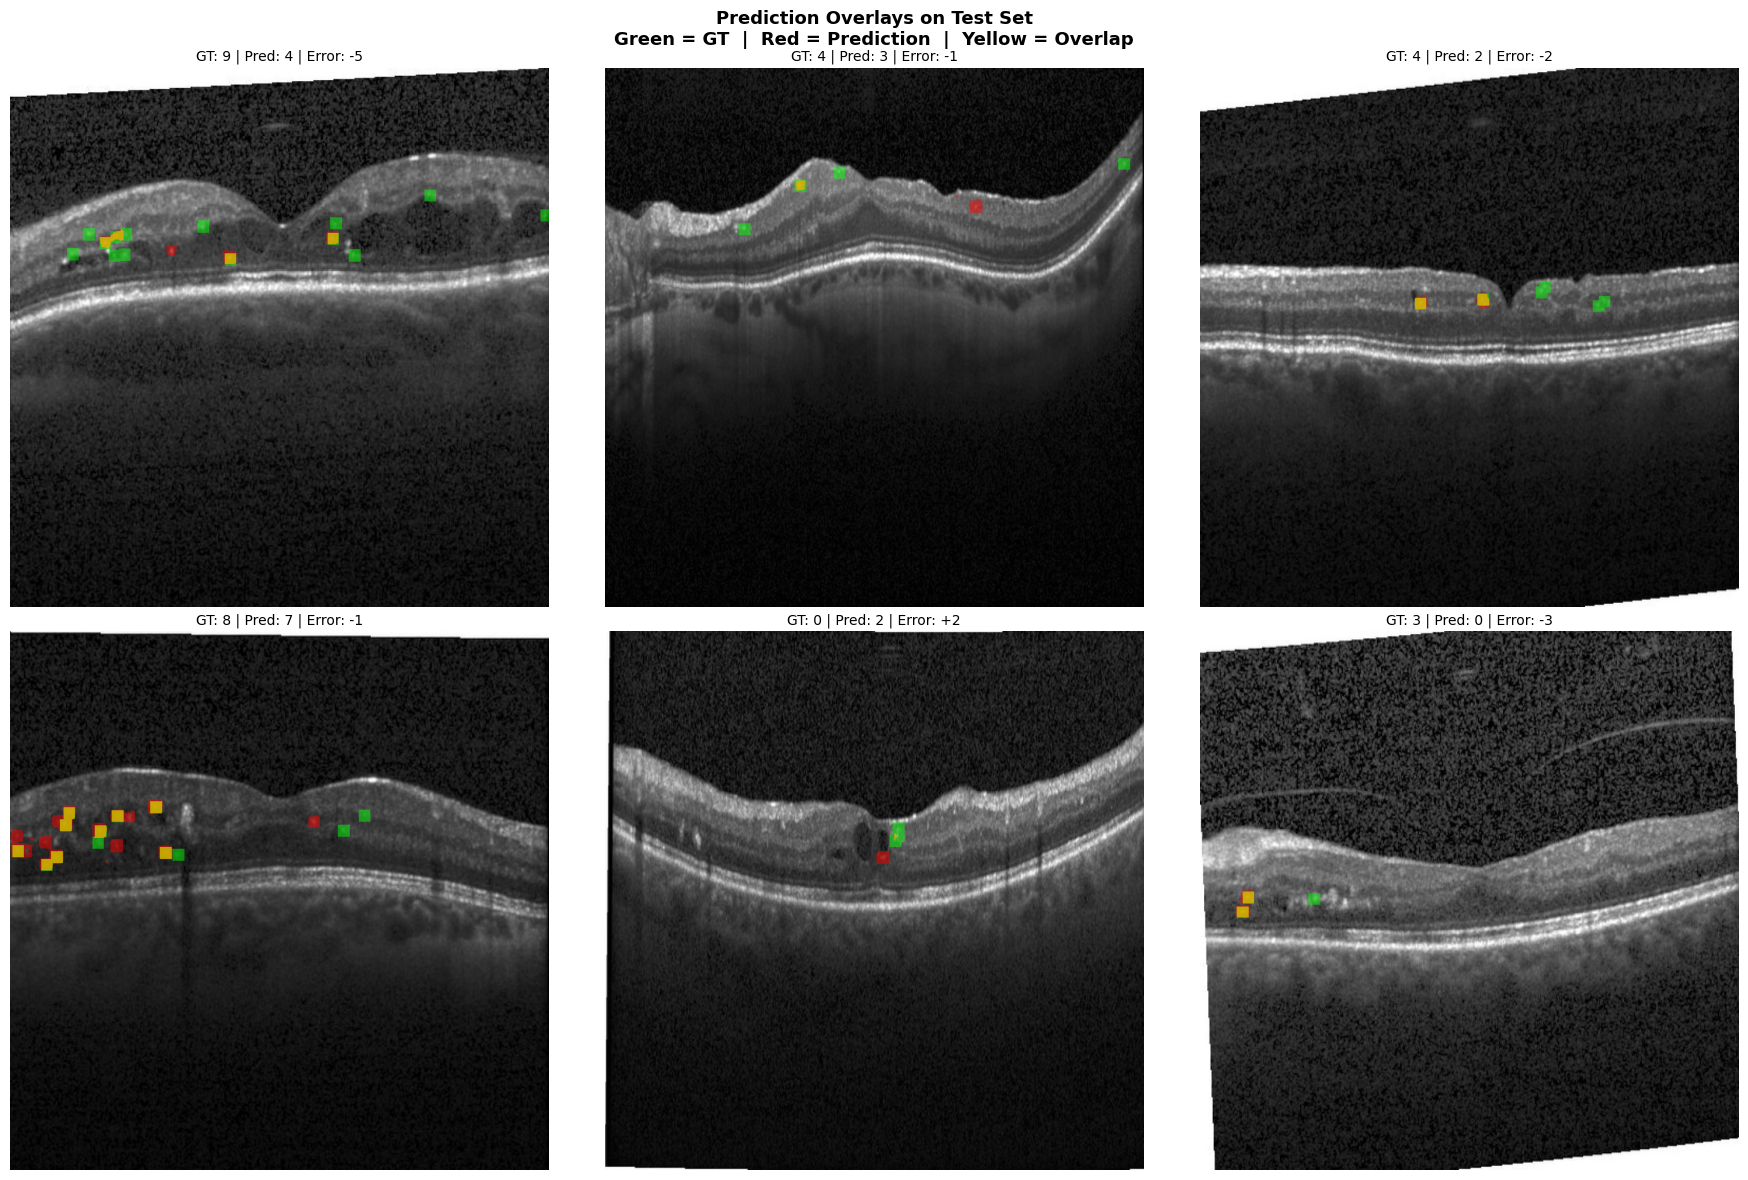

✓ Saved: prediction_overlays.png


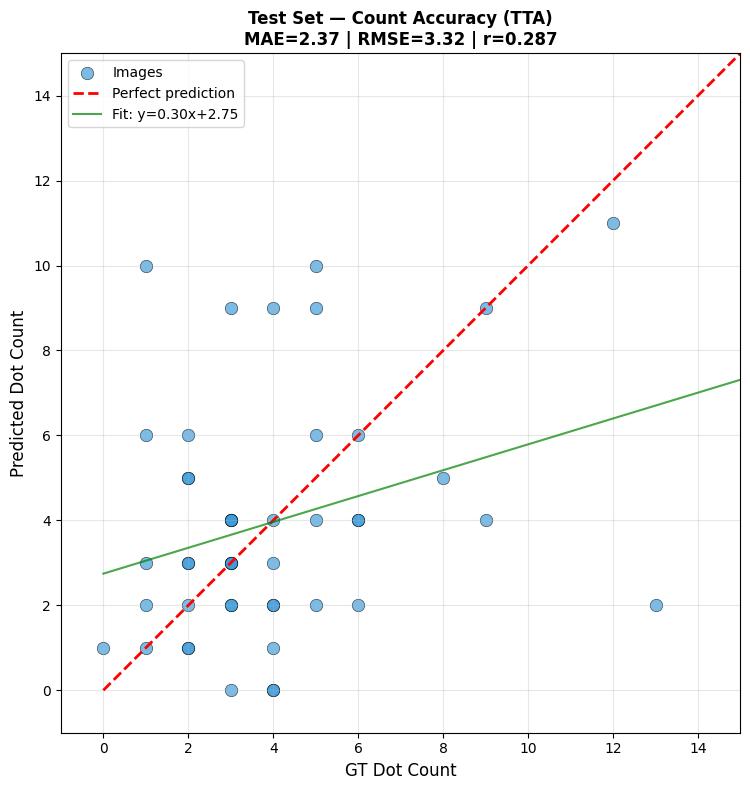

✓ Saved: count_scatter.png


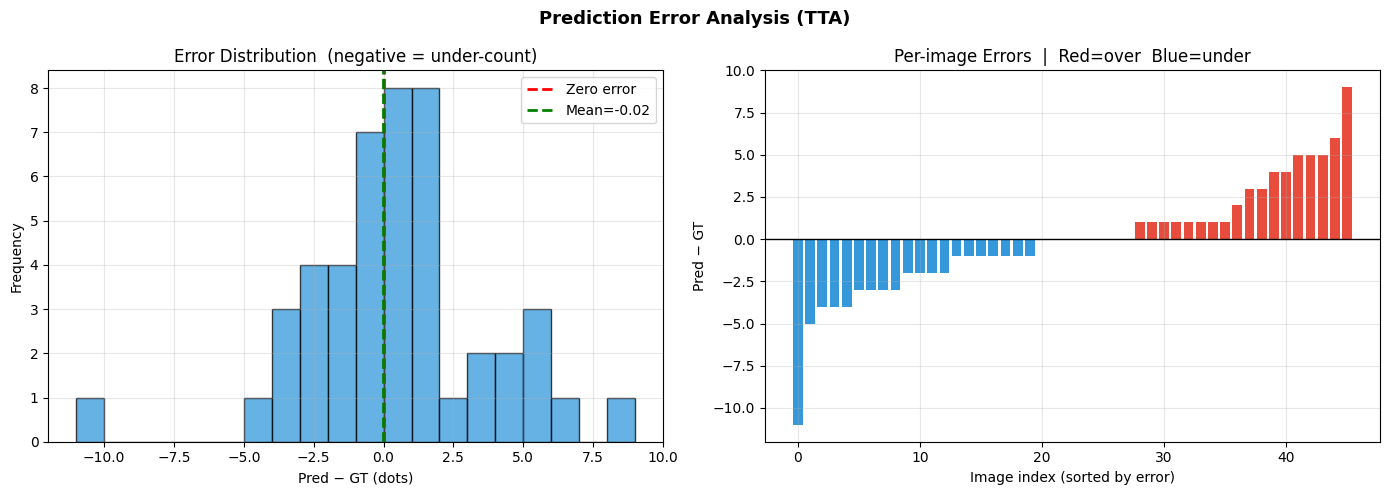

✓ Saved: error_analysis.png


In [29]:
# ── 1. Training curves ────────────────────────────────────────────────────────
if history['train_loss']:
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Training History', fontsize=14, fontweight='bold')

    for ax, key_t, key_v, title, ylab in [
        (axes[0], 'train_loss', 'val_loss', 'Loss (Tversky + Focal)', 'Loss'),
        (axes[1], 'train_dice', 'val_dice', 'Dice Score', 'Dice'),
    ]:
        ax.plot(epochs, history[key_t], 'o-', color='#e74c3c', lw=2, label='Train', ms=3)
        ax.plot(epochs, history[key_v], 's-', color='#3498db', lw=2, label='Val',   ms=3)
        ax.axvline(FREEZE_EPOCHS + 0.5, color='purple', ls=':', lw=2, alpha=0.6,
                   label='Encoder unfrozen')
        best = int(np.argmin(history[key_v]) if 'loss' in key_v else np.argmax(history[key_v]))
        ax.scatter([best+1], [history[key_v][best]], color='gold', s=120,
                   zorder=5, edgecolors='k', label=f'Best (ep {best+1})')
        ax.set_xlabel('Epoch');  ax.set_ylabel(ylab)
        ax.set_title(title);  ax.legend(fontsize=8);  ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
    plt.show()
    print('✓ Saved: training_curves.png')
else:
    print('(No training history — skipping training curves)')


# ── 2. Prediction overlays ────────────────────────────────────────────────────
n_show = min(6, len(test_ds))
idxs   = random.sample(range(len(test_ds)), n_show)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Prediction Overlays on Test Set\n'
             'Green = GT  |  Red = Prediction  |  Yellow = Overlap',
             fontsize=13, fontweight='bold')

for i, idx in enumerate(idxs):
    img_path = os.path.join(test_ds.data_dir, test_ds.imgs[idx])
    xml_path = os.path.join(test_ds.data_dir,
                            os.path.splitext(test_ds.imgs[idx])[0] + '.xml')
    pil_img  = Image.open(img_path).convert('RGB')
    img_np   = np.array(pil_img)
    gt_mask  = xml_to_mask(xml_path, img_np.shape[0], img_np.shape[1])

    _, _, pred_mask = predict_single(model, pil_img, PRED_THRESH)

    overlay = img_np.copy()
    overlay[gt_mask == 1]   = (overlay[gt_mask==1]   * 0.5 + np.array([0,255,0])   * 0.5).astype(np.uint8)
    overlay[pred_mask == 1] = (overlay[pred_mask==1] * 0.5 + np.array([255,0,0])   * 0.5).astype(np.uint8)
    overlap = (gt_mask == 1) & (pred_mask == 1)
    overlay[overlap]        = (overlay[overlap]       * 0.5 + np.array([255,255,0]) * 0.5).astype(np.uint8)

    n_gt   = len(mask_to_dots(gt_mask))
    n_pred = len(mask_to_dots(pred_mask))

    ax = axes[i // 3][i % 3]
    ax.imshow(overlay)
    ax.set_title(f'GT: {n_gt} | Pred: {n_pred} | Error: {n_pred - n_gt:+d}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'prediction_overlays.png'), dpi=150)
plt.show()
print('✓ Saved: prediction_overlays.png')


# ── 3. Count scatter ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(gt_test_tta, pred_test_tta, alpha=0.65, edgecolors='k',
           linewidths=0.5, s=80, color='#3498db', label='Images')
lim = max(gt_test_tta.max(), pred_test_tta.max()) + 2
ax.plot([0, lim], [0, lim], 'r--', lw=2, label='Perfect prediction')
sl, ic, *_ = linregress(gt_test_tta, pred_test_tta)
ax.plot([0, lim], [ic, sl*lim+ic], 'g-', lw=1.5, alpha=0.7,
        label=f'Fit: y={sl:.2f}x+{ic:.2f}')
ax.set_xlabel('GT Dot Count', fontsize=12)
ax.set_ylabel('Predicted Dot Count', fontsize=12)
ax.set_title(f'Test Set — Count Accuracy (TTA)\n'
             f'MAE={mae_tta:.2f} | RMSE={rmse_tta:.2f} | r={corr_tta:.3f}',
             fontsize=12, fontweight='bold')
ax.legend();  ax.grid(True, alpha=0.3);  ax.set_aspect('equal')
ax.set_xlim([-1, lim]);  ax.set_ylim([-1, lim])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'count_scatter.png'), dpi=150)
plt.show()
print('✓ Saved: count_scatter.png')


# ── 4. Error histogram ────────────────────────────────────────────────────────
errors = pred_test_tta - gt_test_tta
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prediction Error Analysis (TTA)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(errors, bins=20, color='#3498db', alpha=0.75, edgecolor='black')
ax.axvline(0,             color='red',   ls='--', lw=2, label='Zero error')
ax.axvline(errors.mean(), color='green', ls='--', lw=2, label=f'Mean={errors.mean():.2f}')
ax.set_xlabel('Pred − GT (dots)');  ax.set_ylabel('Frequency')
ax.set_title('Error Distribution  (negative = under-count)')
ax.legend();  ax.grid(True, alpha=0.3)

ax = axes[1]
order = np.argsort(errors)
ax.bar(range(len(order)), errors[order],
       color=['#e74c3c' if e > 0 else '#3498db' for e in errors[order]])
ax.axhline(0, color='black', lw=1)
ax.set_xlabel('Image index (sorted by error)');  ax.set_ylabel('Pred − GT')
ax.set_title('Per-image Errors  |  Red=over  Blue=under')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'error_analysis.png'), dpi=150)
plt.show()
print('✓ Saved: error_analysis.png')


---
## Section 13 : Save Final Model and Metrics

Saves three artifacts to `/kaggle/working/` (visible in the **Output** tab after the run):
- `unet_final.pth`  full checkpoint (model weights + threshold + history + config)
- `unet_weights.pth`  weights only (smaller, for deployment)
- `metrics.json`  all quantitative results for cross-run comparison


In [30]:
# Full checkpoint
torch.save({
    'model_state_dict' : model.state_dict(),
    'best_threshold'   : float(PRED_THRESH),
    'history'          : history,
    'best_val_dice'    : float(max(history['val_dice'])) if history['val_dice'] else 0.0,
    'min_blob_area'    : MIN_BLOB_AREA,
    'max_blob_area'    : MAX_BLOB_AREA,
    'min_circularity'  : MIN_CIRCULARITY,
    'encoder'          : 'resnet34',
    'attention'        : 'scse',
    'loss'             : 'TverskyFocal_alpha0.3_beta0.7',
    'mask_type'        : 'rectangle',
}, FINAL_MODEL_PATH)
print(f'✓ Full checkpoint:  {FINAL_MODEL_PATH}')

# Weights only (smaller, for deployment)
weights_path = os.path.join(OUTPUT_DIR, 'unet_weights.pth')
torch.save(model.state_dict(), weights_path)
print(f'✓ Weights only:     {weights_path}')

# Metrics JSON
metrics = {
    'test_mae_no_tta'  : float(mae_1),
    'test_mae_tta'     : float(mae_tta),
    'test_rmse_no_tta' : float(rmse_1),
    'test_rmse_tta'    : float(rmse_tta),
    'test_corr_no_tta' : float(corr_1),
    'test_corr_tta'    : float(corr_tta),
    'best_threshold'   : float(PRED_THRESH),
    'best_val_dice'    : float(max(history['val_dice'])) if history['val_dice'] else 0.0,
    'min_blob_area'    : MIN_BLOB_AREA,
    'max_blob_area'    : MAX_BLOB_AREA,
}
metrics_path = os.path.join(OUTPUT_DIR, 'metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'✓ Metrics JSON:     {metrics_path}')

print('\n' + '='*55)
print('SUMMARY')
print('='*55)
print(f'  Test MAE   no TTA : {mae_1:.2f} dots/image')
print(f'  Test MAE   TTA×8  : {mae_tta:.2f} dots/image')
print(f'  Test RMSE  TTA×8  : {rmse_tta:.2f}')
print(f'  Test Corr  TTA×8  : {corr_tta:.3f}')
print(f'  Best Val Dice     : {metrics["best_val_dice"]:.4f}')
print(f'  Threshold used    : {PRED_THRESH:.2f}')
print('='*55)
print('\nAll outputs saved to /kaggle/working/ — visible in the Output tab.')


✓ Full checkpoint:  /kaggle/working/unet_final.pth
✓ Weights only:     /kaggle/working/unet_weights.pth
✓ Metrics JSON:     /kaggle/working/metrics.json

SUMMARY
  Test MAE   no TTA : 3.11 dots/image
  Test MAE   TTA×8  : 2.37 dots/image
  Test RMSE  TTA×8  : 3.32
  Test Corr  TTA×8  : 0.287
  Best Val Dice     : 0.4008
  Threshold used    : 0.90

All outputs saved to /kaggle/working/ — visible in the Output tab.
